<a href="https://colab.research.google.com/github/geogav/morphophen_networks_spatial/blob/main/notebooks/Morphophen_Single_cell.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Author: George Gavriilidis

Material is sourced mainly from the https://www.sc-best-practices.org/preamble.html

# **Single-cell basic analysis**

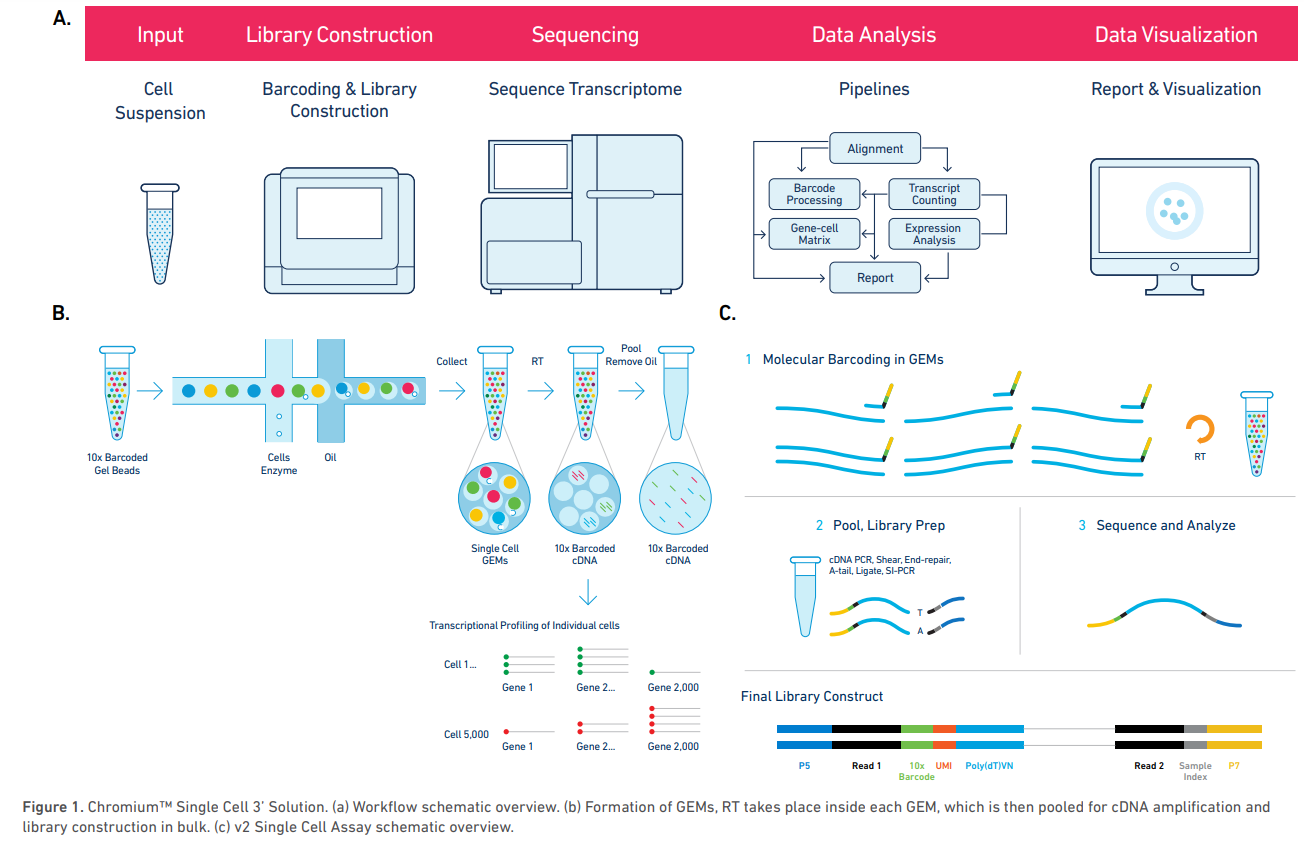

# **Dataset Overview: Human Organoids Study**

## **Data Description**
In this analysis, we will work with **human organoid** data obtained from the **GEO database**. The dataset provides transcriptomic information from **wild-type (WT) human organoids**, allowing us to study gene expression patterns and network interactions.

## **Dataset Details**
| **Attribute** | **Details** |
|--------------|------------|
| **Source Name** | Human organoids |
| **Organism** | *Homo sapiens* |
| **Characteristics** | Tissue: Human organoids |
|  | Genotype: Wild-type (WT) |

This dataset is available from the **GEO repository** at the following link:  
[**GSM7732411 - GEO Accession**](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSM7732411)

## **Objective of the Analysis**
- Explore **gene expression patterns** in human organoids.  
- Examine how QC affects clustering
-

This study provides insights into **wild-type human organoids**, which serve as a model for understanding **cellular differentiation, disease mechanisms, and therapeutic applications**.

# Dependencies

In [ ]:
pip install --upgrade scanpy

In [ ]:
# Core scverse libraries
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc

# Core scverse libraries
import scanpy as sc
import anndata as ad

# Data retrieval
import pooch

In [ ]:
# Locating you working directory
!pwd

# Data Preprocessing

<img src="https://raw.githubusercontent.com/scverse/anndata/main/docs/_static/img/anndata_schema.svg" width="500" height="500">

This is the architecture of Anndata object, which is the core of `Scanpy`/`scverse` analysis of single-cell datasets.

# **Quick Notes on AnnData Format**

## **What is AnnData?**
AnnData (`anndata.AnnData`) is a data structure optimized for **single-cell omics** analysis, storing gene expression data along with metadata.

## **Main Components**
- **`.X`** → The main data matrix (sparse or dense), usually UMI counts or normalized expression.
- **`.obs`** → Cell metadata (e.g., `cell_type`, `batch`, `total_counts`).
- **`.var`** → Gene metadata (e.g., `gene_symbols`, `highly_variable`).
- **`.obsm`** → Embeddings (e.g., `X_pca`, `X_umap`).
- **`.uns`** → Unstructured data (e.g., clustering results, visualization settings).
- **`.layers`** → Alternative data representations (e.g., `raw`, `log1p`, `scaled`).

## **Example: Loading and Inspecting AnnData**
```python
import scanpy as sc

adata = sc.read_h5ad("dataset.h5ad")  # Load an AnnData file
print(adata)  # Quick overview
print(adata.obs.head())  # Check cell metadata
print(adata.var.head())  # Check gene metadata


# **Essential Components for Assembling an AnnData Object in Scanpy**

## **1. Core Data Matrices**
- **`.X`** → The primary data matrix (usually UMI counts or normalized expression values).
- **`adata.layers["counts"]`** → Stores raw counts separately from normalized data.
- **`adata.raw`** → Preserves raw untransformed data before normalization or log transformation.

## **2. Gene and Cell Metadata**
- **`adata.var`** → Contains gene-level metadata (e.g., gene names, feature selection).
  - Example columns: `gene_ids`, `highly_variable`, `mt_gene`
- **`adata.obs`** → Contains cell-level metadata (e.g., sample ID, clustering labels).
  - Example columns: `cell_type`, `patient_id`, `n_genes_by_counts`, `percent_mito`

## **3. Quality Control Metrics**
- **`n_genes_by_counts`** → Number of detected genes per cell.
- **`total_counts`** → Total UMI counts per cell.
- **`pct_counts_mt`** → Percentage of mitochondrial reads (indicator of cell stress).

## **4. Dimensionality Reduction and Embeddings**
- **`adata.obsm["X_pca"]`** → Principal Component Analysis (PCA) embedding.
- **`adata.obsm["X_umap"]`** → Uniform Manifold Approximation and Projection (UMAP) embedding.
- **`adata.obsm["X_tsne"]`** → t-SNE embedding.

## **5. Clustering and Cell Annotations**
- **`adata.obs["leiden"]`** → Leiden clustering labels.
- **`adata.obs["louvain"]`** → Louvain clustering labels.
- **`adata.obs["cell_type"]`** → Manual or automated cell type annotations.

## **6. Graph-Based Representations (for Clustering)**
- **`adata.obsp["distances"]`** → KNN graph distance matrix.
- **`adata.obsp["connectivities"]`** → Graph connectivities used in clustering.

## **7. Differential Expression Results**
- **`adata.uns["rank_genes_groups"]`** → Stores results from differential expression analysis (e.g., Wilcoxon test).
- **`adata.uns["log1p"]`** → Information on log-transformed data.

## **8. Storing Additional Layers**
- **`adata.layers["log1p"]`** → Log-transformed expression values.
- **`adata.layers["normalized"]`** → Total-count normalized values.
- **`adata.layers["scaled"]`** → Z-score scaled data for visualization.

---

### **Loading Data into AnnData**
#### **From 10X Genomics**
```python
import scanpy as sc

adata = sc.read_10x_mtx(
    "path/to/filtered_feature_bc_matrix/",
    var_names="gene_symbols",
    cache=True
)


## Loading in Scanpy

## PBMC

In [ ]:
EXAMPLE_DATA = pooch.create(
    path=pooch.os_cache("scverse_tutorials"),
    base_url="doi:10.6084/m9.figshare.22716739.v1/",
)
EXAMPLE_DATA.load_registry_from_doi()

In [ ]:
samples = {
    "s1d1": "s1d1_filtered_feature_bc_matrix.h5",
    "s1d3": "s1d3_filtered_feature_bc_matrix.h5",
}
adatas = {}

for sample_id, filename in samples.items():
    path = EXAMPLE_DATA.fetch(filename)
    sample_adata = sc.read_10x_h5(path)
    sample_adata.var_names_make_unique()
    adatas[sample_id] = sample_adata

adata = ad.concat(adatas, label="sample")
adata.obs_names_make_unique()
print(adata.obs["sample"].value_counts())
adata

## Organoids

In [ ]:
# Load data into Scanpy

In [ ]:
# !pip install gdown

In [ ]:
# # We download the necessary files for assembling the single-cell object from Google Drive which are in typical 10x format post-Cell Ranger
# !gdown --id 1cDTjLg7yn9ApH6YBClEz3cPNraFMVtWp -O organoids.tar.gz

In [ ]:
# # Decompressing
# !tar -xzvf organoids.tar.gz

In [ ]:
# # Path to the folder containing the matrix, barcodes, and genes files
# data_folder = "./organoids"

# # Load the data
# adata = sc.read_10x_mtx(
#     data_folder,       # Path to the folder containing the files
#     var_names='gene_symbols',  # Use gene symbols for variable names
#     cache=True         # Cache the result for faster reloading
# )

# # Inspect the loaded data
# print(adata)

# Quality Control (QC)

## Importance of Quality Control in Single-Cell Analysis

## Introduction
Single-cell RNA sequencing (scRNA-seq) has revolutionized our ability to study cellular heterogeneity and transcriptional dynamics at an unprecedented resolution. However, the high sensitivity of this technique makes it particularly susceptible to technical noise and artifacts. Quality control (QC) is a critical step in single-cell analysis to ensure reliable and biologically meaningful results.

## Key Reasons for Quality Control

### 1. **Removal of Low-Quality Cells**
- Some cells may have low RNA content or be damaged during sample preparation, leading to incomplete transcriptomes.
- Cells with an unusually high percentage of mitochondrial reads indicate potential cell stress or apoptosis.
- Filtering out low-quality cells improves downstream clustering and differential expression analyses.

### 2. **Mitigating Technical Artifacts**
- Doublets (two or more cells captured in a single droplet) can artificially inflate gene expression levels.
- Ambient RNA contamination can introduce misleading transcripts into cell profiles.
- Normalization and batch correction techniques help reduce unwanted technical variation.

### 3. **Ensuring Accurate Cell-Type Identification**
- Cells with insufficient feature counts or high dropout rates can distort clustering and cell annotation.
- Proper QC ensures that the final dataset reflects true biological heterogeneity rather than sequencing artifacts.

### 4. **Enhancing Reproducibility and Comparability**
- Poor-quality data can lead to irreproducible results that fail validation in independent experiments.
- QC allows for standardization across datasets, improving comparability in large-scale studies or meta-analyses.

### 5. **Optimizing Computational Performance**
- Retaining only high-quality cells reduces computational costs and prevents downstream analyses from being overwhelmed by noisy data.
- Streamlining datasets ensures more accurate and efficient clustering, trajectory inference, and gene regulatory network modeling.

## Common Quality Control Metrics

| Metric               | Description                                       | Common Thresholds |
|----------------------|-------------------------------------------------|-------------------|
| **Library Size**     | Total number of detected reads per cell         | Remove extreme outliers |
| **Feature Count**    | Number of unique genes detected per cell       | Filter cells with too few genes (< 500) |
| **Mitochondrial Content** | Percentage of mitochondrial reads          | Typically < 10% |
| **Doublet Score**    | Predicted probability of a cell being a doublet | Remove high-score doublets |
| **UMI Count**        | Number of unique molecular identifiers per cell | Normalize across cells |

## Conclusion
Quality control is an indispensable step in single-cell analysis to ensure that data reflects true biological variation rather than technical noise. Implementing stringent QC procedures improves the accuracy, reproducibility, and interpretability of single-cell studies, ultimately leading to more robust biological insights.

---

### Further Reading
- Luecken & Theis, 2019. *Current best practices in single-cell RNA-seq analysis*.
- Ilicic et al., 2016. *Classification of low-quality cells in single-cell RNA-seq data*.
- Andrews & Hemberg, 2018. *Identifying cell populations with scRNA-seq*.


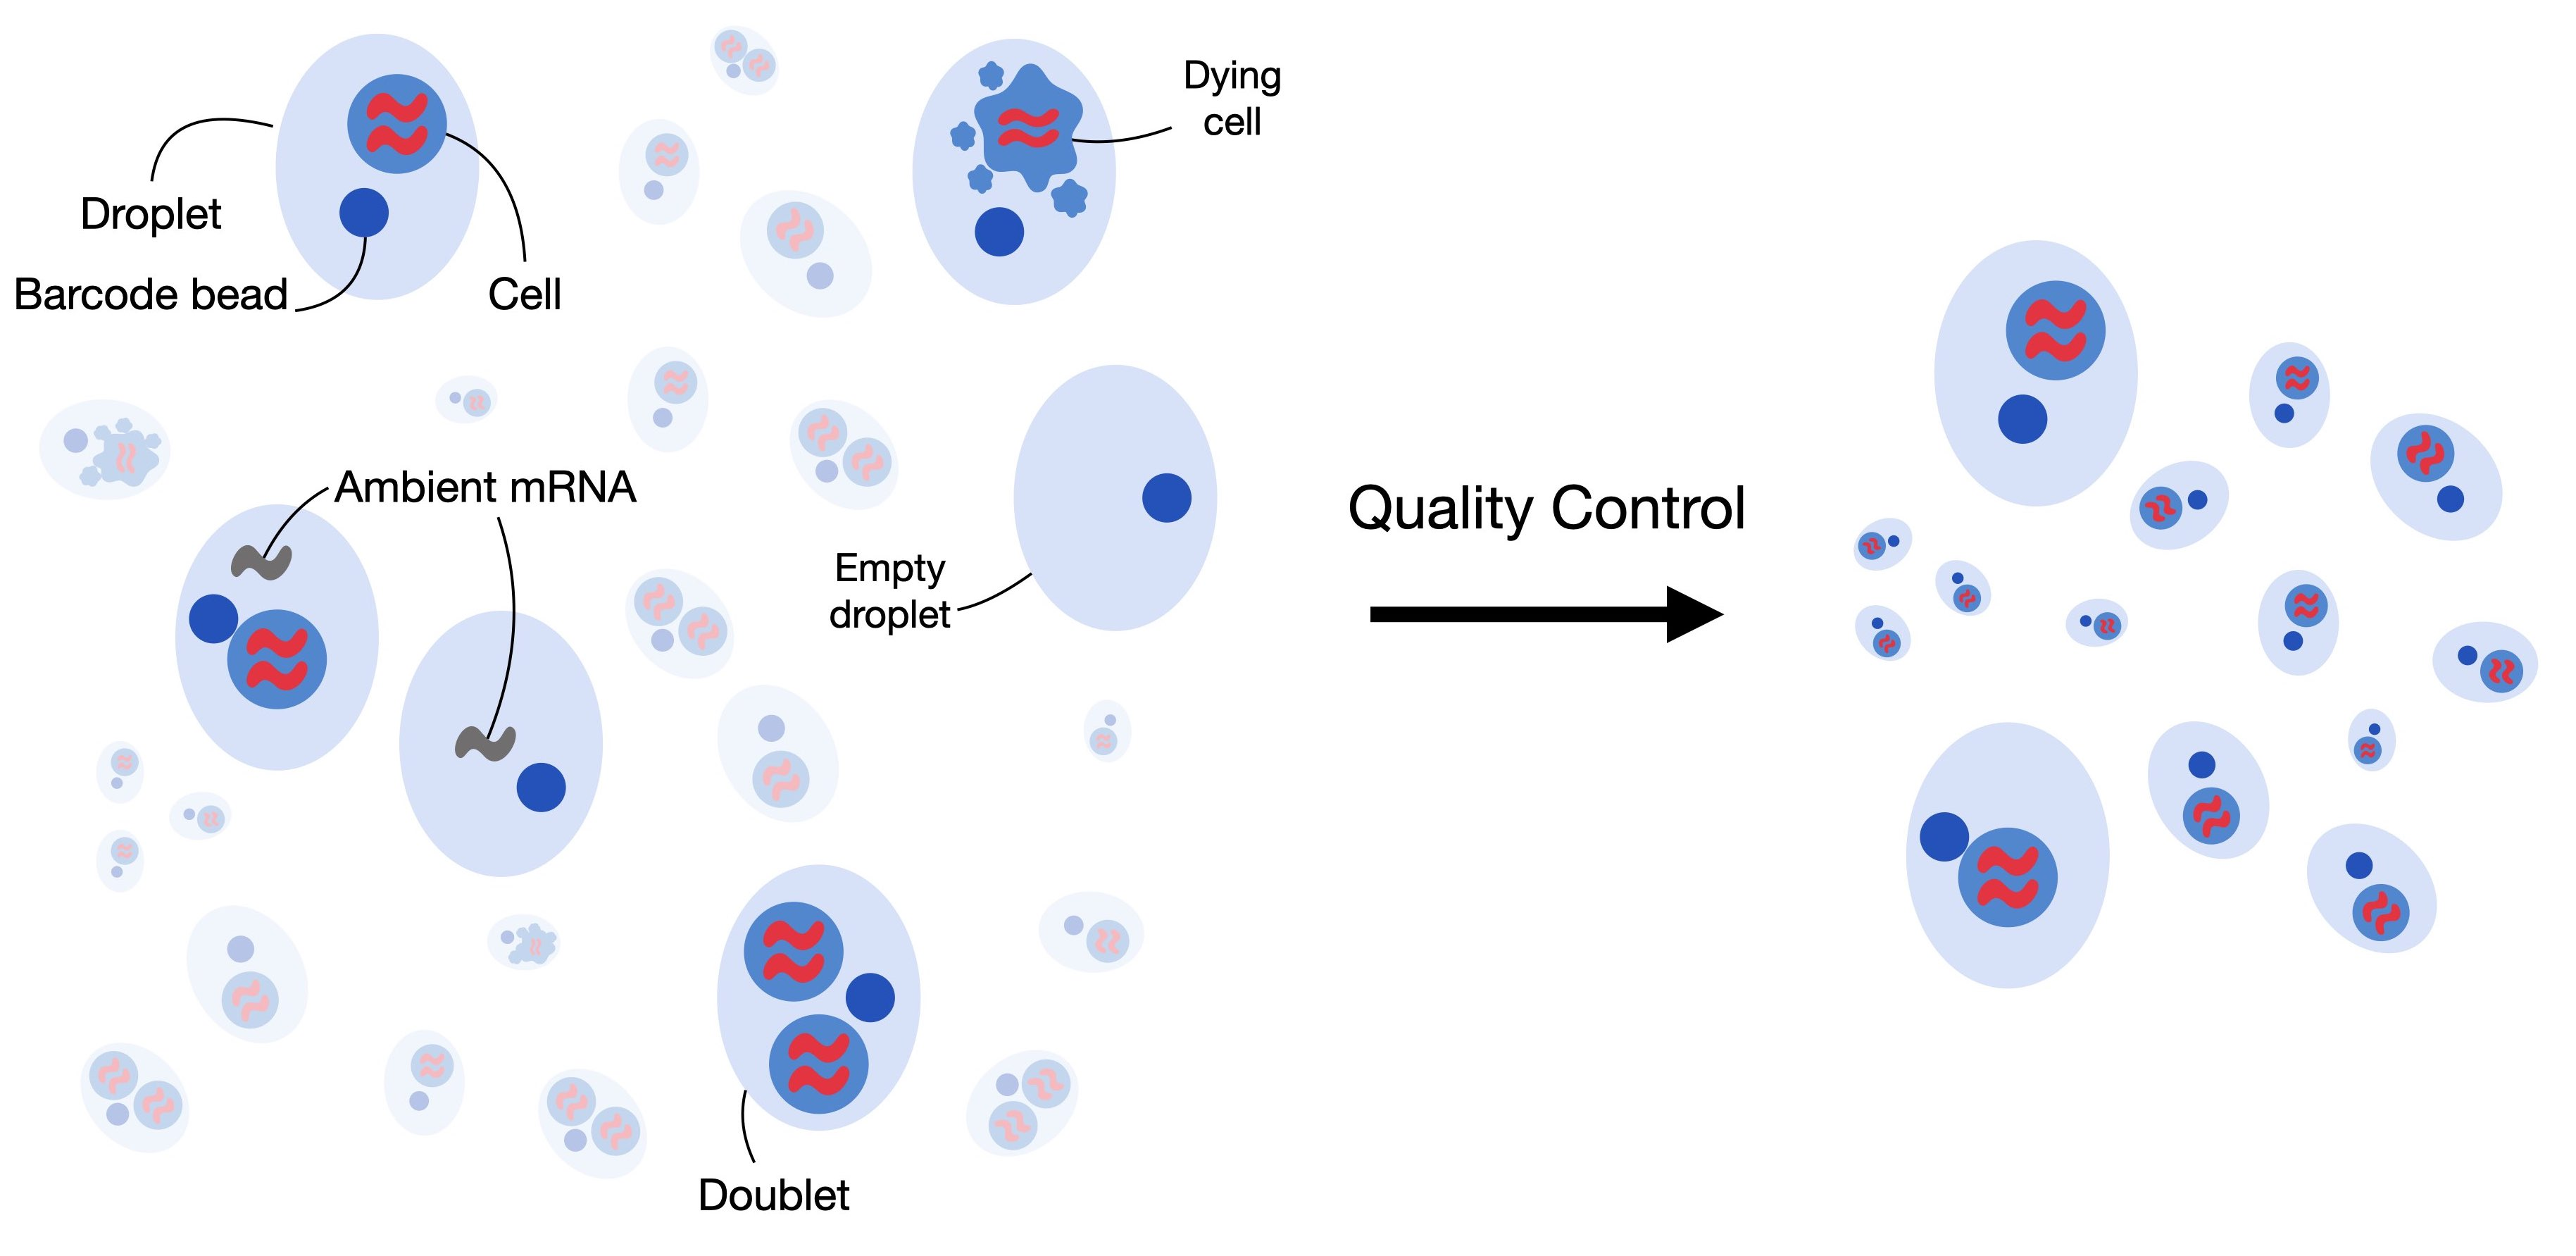

Single-cell RNA-seq datasets can contain low-quality cells, cell-free RNA and doublets. Quality control aims to remove and correct for those to obtain a high-quality dataset where each observation is an intact single cell

In [ ]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [ ]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

In [ ]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo", "pct_counts_hb"],
    jitter=0.4,
    multi_panel=True,
)

Some additional metrics to consider are ribosomal and HB gene content, here is why:

| **Feature**           | **Why QC?**                                                              | **Action**                                |
|----------------------|-------------------------------------------------------------------------|-------------------------------------------|
| **Ribosomal Genes (rRNA)** | High expression may indicate technical biases, poor poly-A selection, or stressed cells. | Remove cells with **`pct_ribo > 20%`**   |
| **Hemoglobin Genes (HB)**  | High expression in non-erythroid cells suggests RBC contamination or lysis inefficiency. | Remove cells with **`pct_hb > 5-10%`** (unless working with blood samples) |


In [ ]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

**What is this relationship telling us?**

The analyst usually decides filtering, but automated methods for QC are appearing on the horizon.

In [ ]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

In [ ]:
adata = adata[adata.obs.n_genes_by_counts < 2000, :]
adata = adata[adata.obs.pct_counts_mt < 10, :].copy()

In [ ]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo", "pct_counts_hb"],
    jitter=0.4,
    multi_panel=True,
)

## Doublet detection

### **Why is Doublet Detection Important in Single-Cell RNA-Seq?**  

### **1. Prevents Artificial Cell States**  
- Doublets (two cells captured in one droplet) **mimic hybrid transcriptomes**, leading to false cell states.  

### **2. Improves Clustering Accuracy**  
- Doublets **distort clustering** by introducing mixed cell identities, affecting downstream analyses.  

### **3. Avoids Misleading Differential Expression (DE) Analysis**  
- Artificial gene expression profiles can **skew DE results**, leading to incorrect biological interpretations.  

### **4. Essential for High Cell Recovery Protocols**  
- Higher cell loading increases **doublet formation (~5-10% in standard 10x runs, higher in high-throughput methods)**.  

### **5. Doublet Detection Methods**  
- **Experimental**: Use **multiplet rate estimates** based on cell loading density.  
- **Computational**: Use tools like **Scrublet, DoubletFinder, scDblFinder** to identify and filter doublets.  


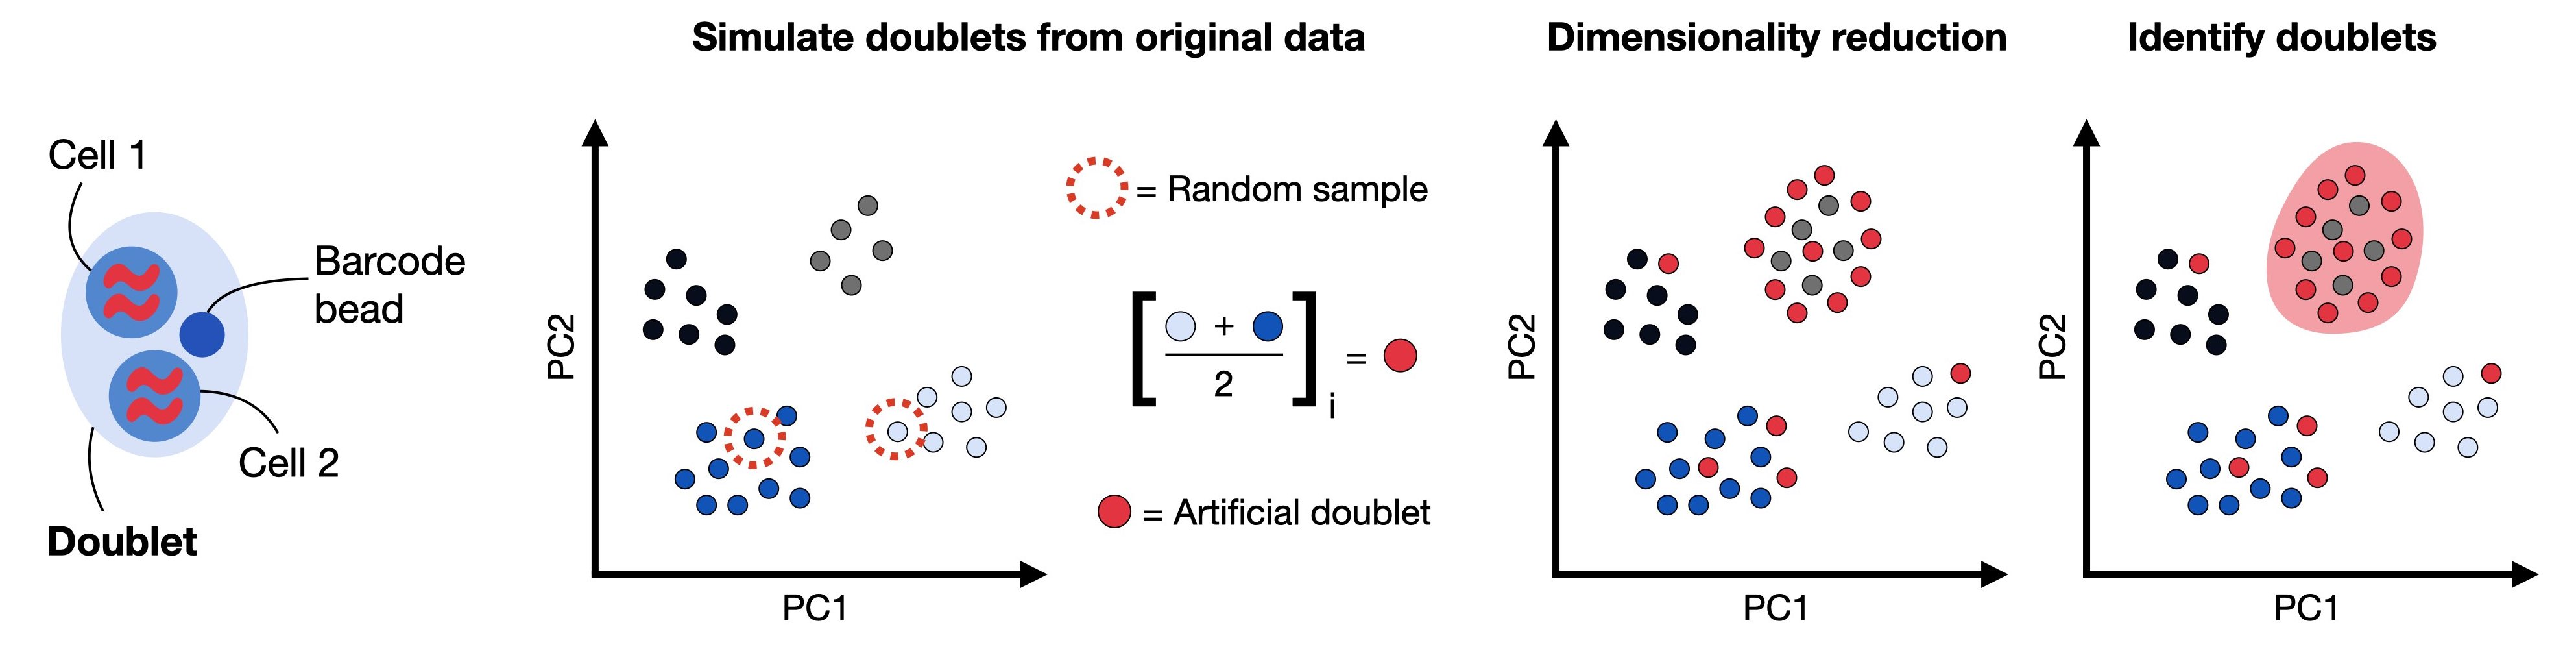

In [ ]:
!pip install scikit-image

In [ ]:
sc.pp.scrublet(adata)

In [ ]:
adata = adata[~adata.obs["predicted_doublet"], :].copy()

# Normalisation

In [ ]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

In [ ]:
adata_backup = adata

In [ ]:
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

# Feature Selection

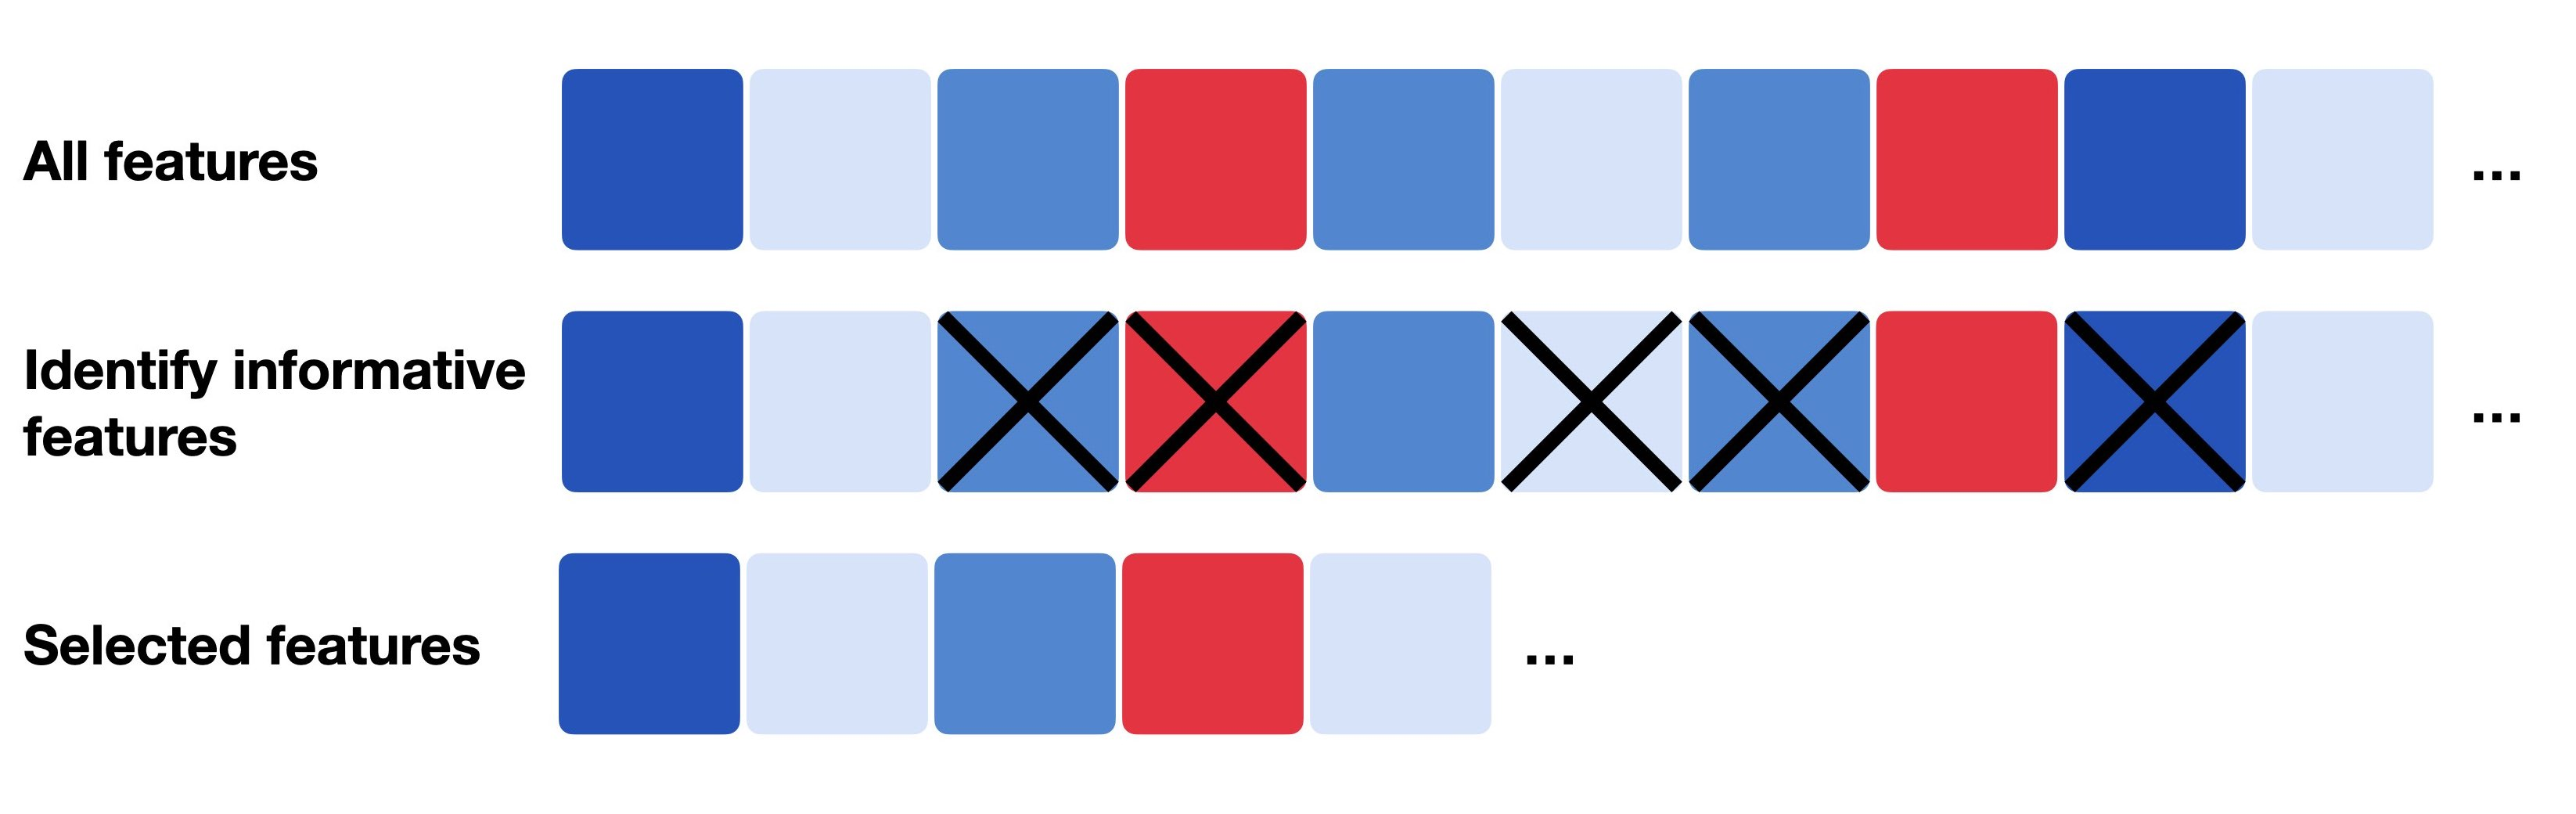

Feature selection generally describes the process of only selecting a subset of relevant features which can be the most informative, most variable or most deviant ones

In [ ]:
sc.pp.highly_variable_genes(adata, n_top_genes=5000)

In [ ]:
sc.pl.highly_variable_genes(adata)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract relevant data
mean = adata.var["means"]  # Mean expression per gene
dispersion = adata.var["dispersions"]  # Raw dispersion
hvg_mask = adata.var["highly_variable"]  # Boolean mask for HVGs

# Create figure
plt.figure(figsize=(8, 6))

# Scatter plot of all genes (light gray for visibility)
sns.scatterplot(x=mean, y=dispersion, s=5, alpha=0.3, label="All Genes", color="gray")

# Scatter plot of HVGs (highlighted in red, semi-transparent)
sns.scatterplot(x=mean[hvg_mask], y=dispersion[hvg_mask], color="red", s=8, alpha=0.6, label="HVGs")

# Set log-log scale
plt.xscale("log")
plt.yscale("log")

# Labels and title
plt.xlabel("Mean Expression")
plt.ylabel("Dispersion")
plt.title("Mean-Dispersion Relationship (Without Fitted Trend)")

# Display legend
plt.legend()
plt.tight_layout()
plt.show()


# Dimensionality Reduction

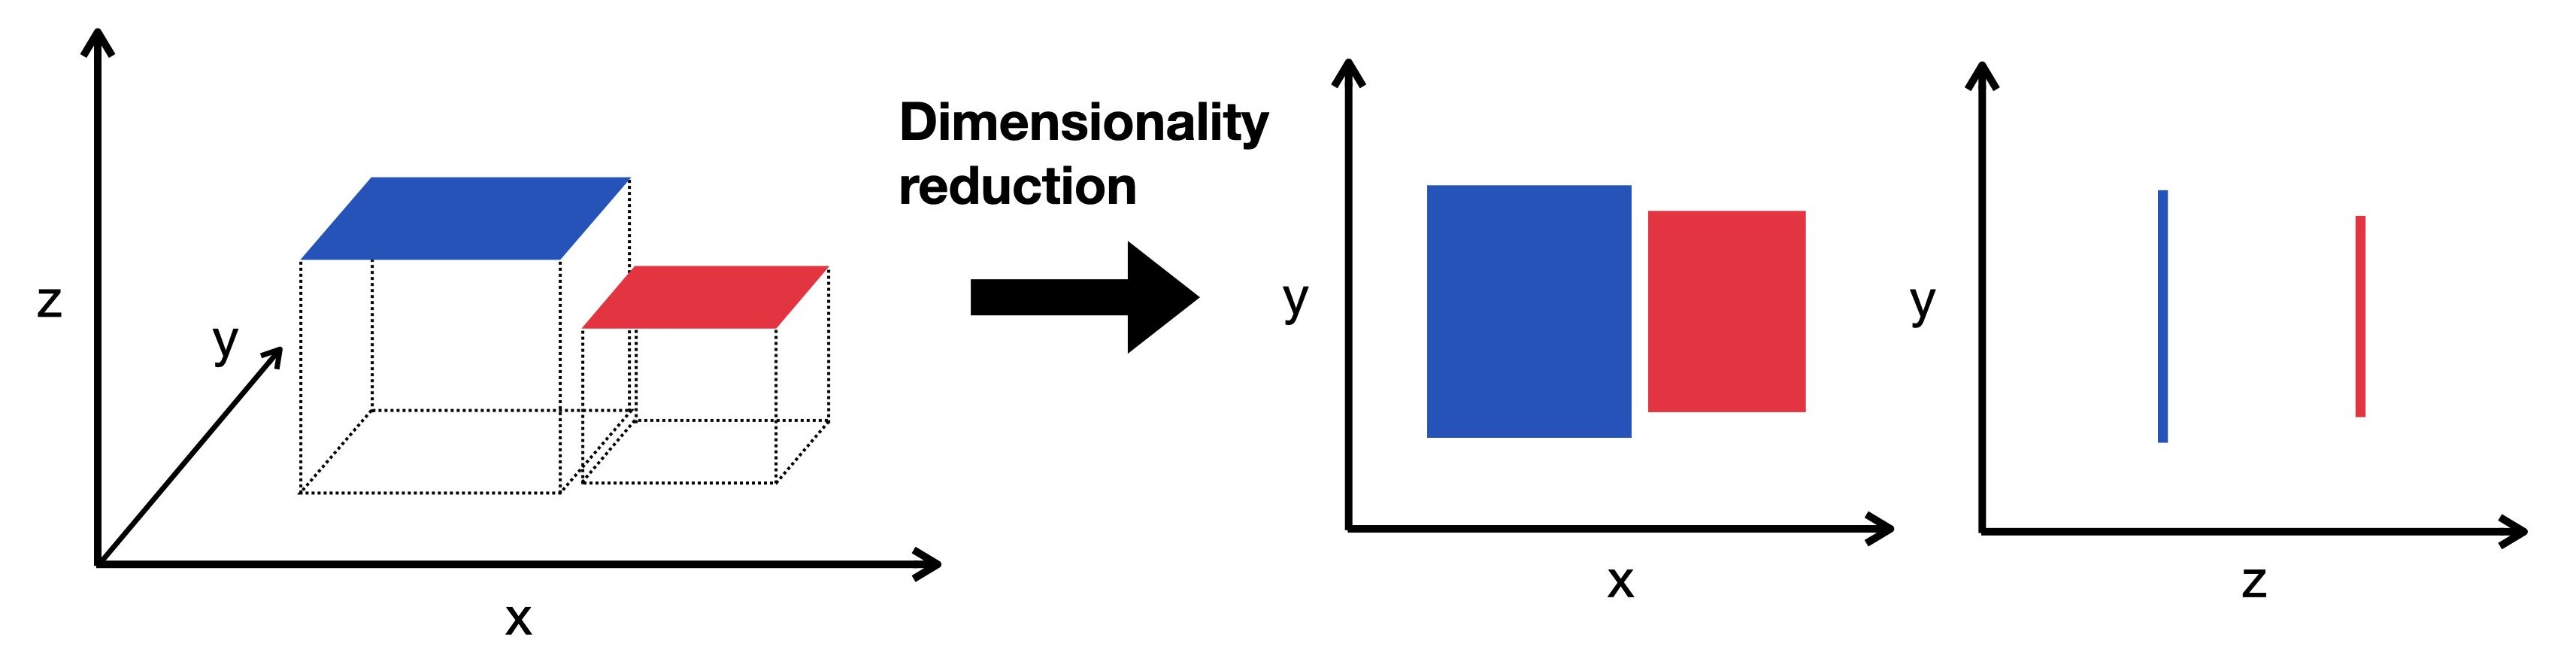

 Dimensionality reduction embeds the high-dimensional data into a lower dimensional space. The low-dimensional representation still captures the underlying structure of the data while having as few as possible dimensions. Here we visualize a three dimensional object projected into two dimensions.

In [ ]:
sc.tl.pca(adata)

In [ ]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

How can you select the appropriate number of PCs for the following steps? What happens if you select only 10 or 5?

# Nearest neighbor graph constuction, clustering and visualization

In [ ]:
sc.pp.neighbors(adata)

In [ ]:
sc.tl.umap(adata)

In [ ]:
!pip3 install igraph
!pip3 install leidenalg

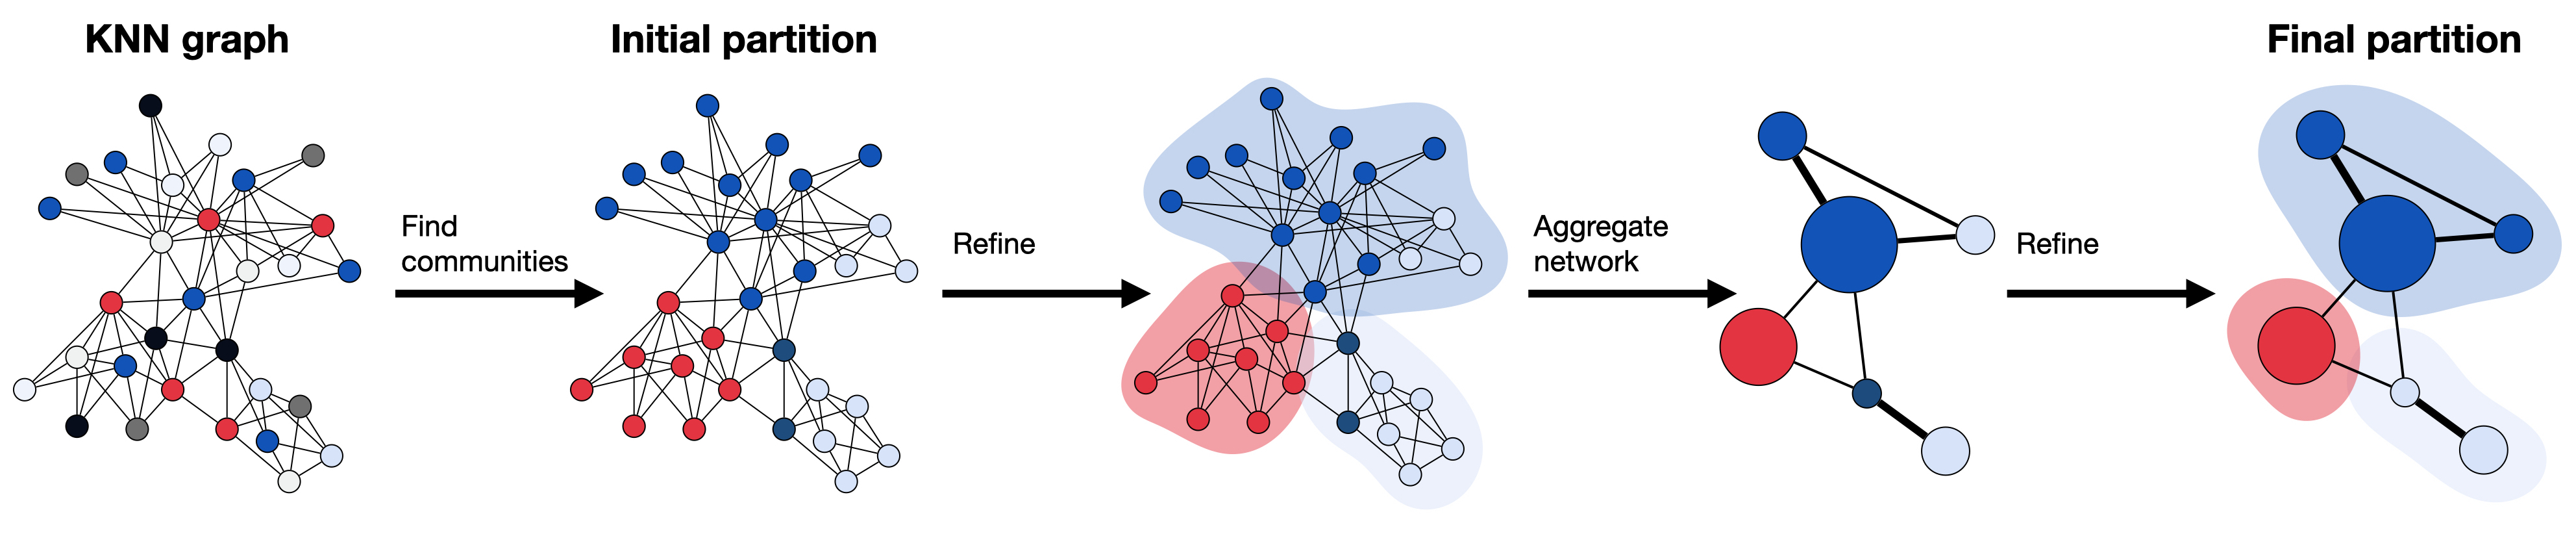

The Leiden algorithm computes a clustering on a KNN graph obtained from the PC reduced expression space. It starts with an initial partition where each node from its own community. Next, the algorithm moves single nodes from one community to another to find a partition, which is then refined. Based on a refined partition an aggregate network is generated, which is again refined until no further improvements can be obtained, and the final partition is reached

In [ ]:
# Using the igraph implementation and a fixed number of iterations can be significantly faster, especially for larger datasets
sc.tl.leiden(adata, flavor="igraph", n_iterations=2, resolution = 0.1)

In [ ]:
sc.pl.pca(adata, color = "leiden")

In [ ]:
sc.pl.umap(adata, color=["leiden"])

❓**How can we change the number of clusters?**

❓**Why is PCA different than UMAP?**

❓**Where would you study trajectory pseudotime?**

# Marker genes

We are going to perform differential analysis in the concept of "one-vs-rest"
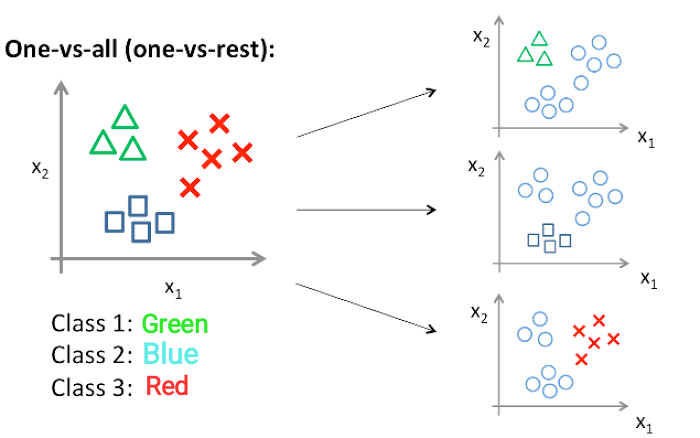

In [ ]:
# Obtain cluster-specific differentially expressed genes
sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon")

In [ ]:
# Obtain cluster-specific differentially expressed genes
sc.pl.rank_genes_groups_dotplot(
    adata, groupby="leiden", standard_scale="var", n_genes=5
)

In [ ]:
adata

In [ ]:
adata.var["highly_variable"]

In [ ]:
hvg_genes = adata.var.index[adata.var["highly_variable"]].tolist()
print(f"Number of highly variable genes: {len(hvg_genes)}")
print(hvg_genes[:10])  # Print first 10 HVGshvg = adata.var.index[adata.var["highly_variable"]].tolist()  # Boolean mask,

In [ ]:
adata_v1 = adata

# Cell type annotation

 🧬 Cell Annotation in Single-Cell Analysis

📌 Overview
Cell annotation is a crucial step in single-cell RNA-seq analysis to assign biological identities to clusters of cells.

🔹 1. Preprocessing for Annotation
Before annotation, ensure the dataset is well-prepared:
- **Quality control**: Filter low-quality cells with high mitochondrial content.
- **Normalization**: Apply `sc.pp.normalize_total()` or `sctransform`.
- **Feature selection**: Identify highly variable genes with `sc.pp.highly_variable_genes()`.
- **Dimensionality reduction**: Perform PCA and UMAP for visualization.

🔹 2. Methods for Cell Annotation
There are three common approaches:

🏷️ **A. Marker-Based Annotation**
Manual curation using known marker genes.
```python
# Example: Visualizing marker gene expression
sc.pl.umap(adata, color=["CD3E", "MS4A1", "LYZ", "EPCAM"])


CellTypist is an automated cell type annotation tool for scRNA-seq datasets on the basis of logistic regression classifiers optimised by the stochastic gradient descent algorithm. CellTypist allows for cell prediction using either built-in (with a current focus on immune sub-populations) or custom models, in order to assist in the accurate classification of different cell types and subtypes.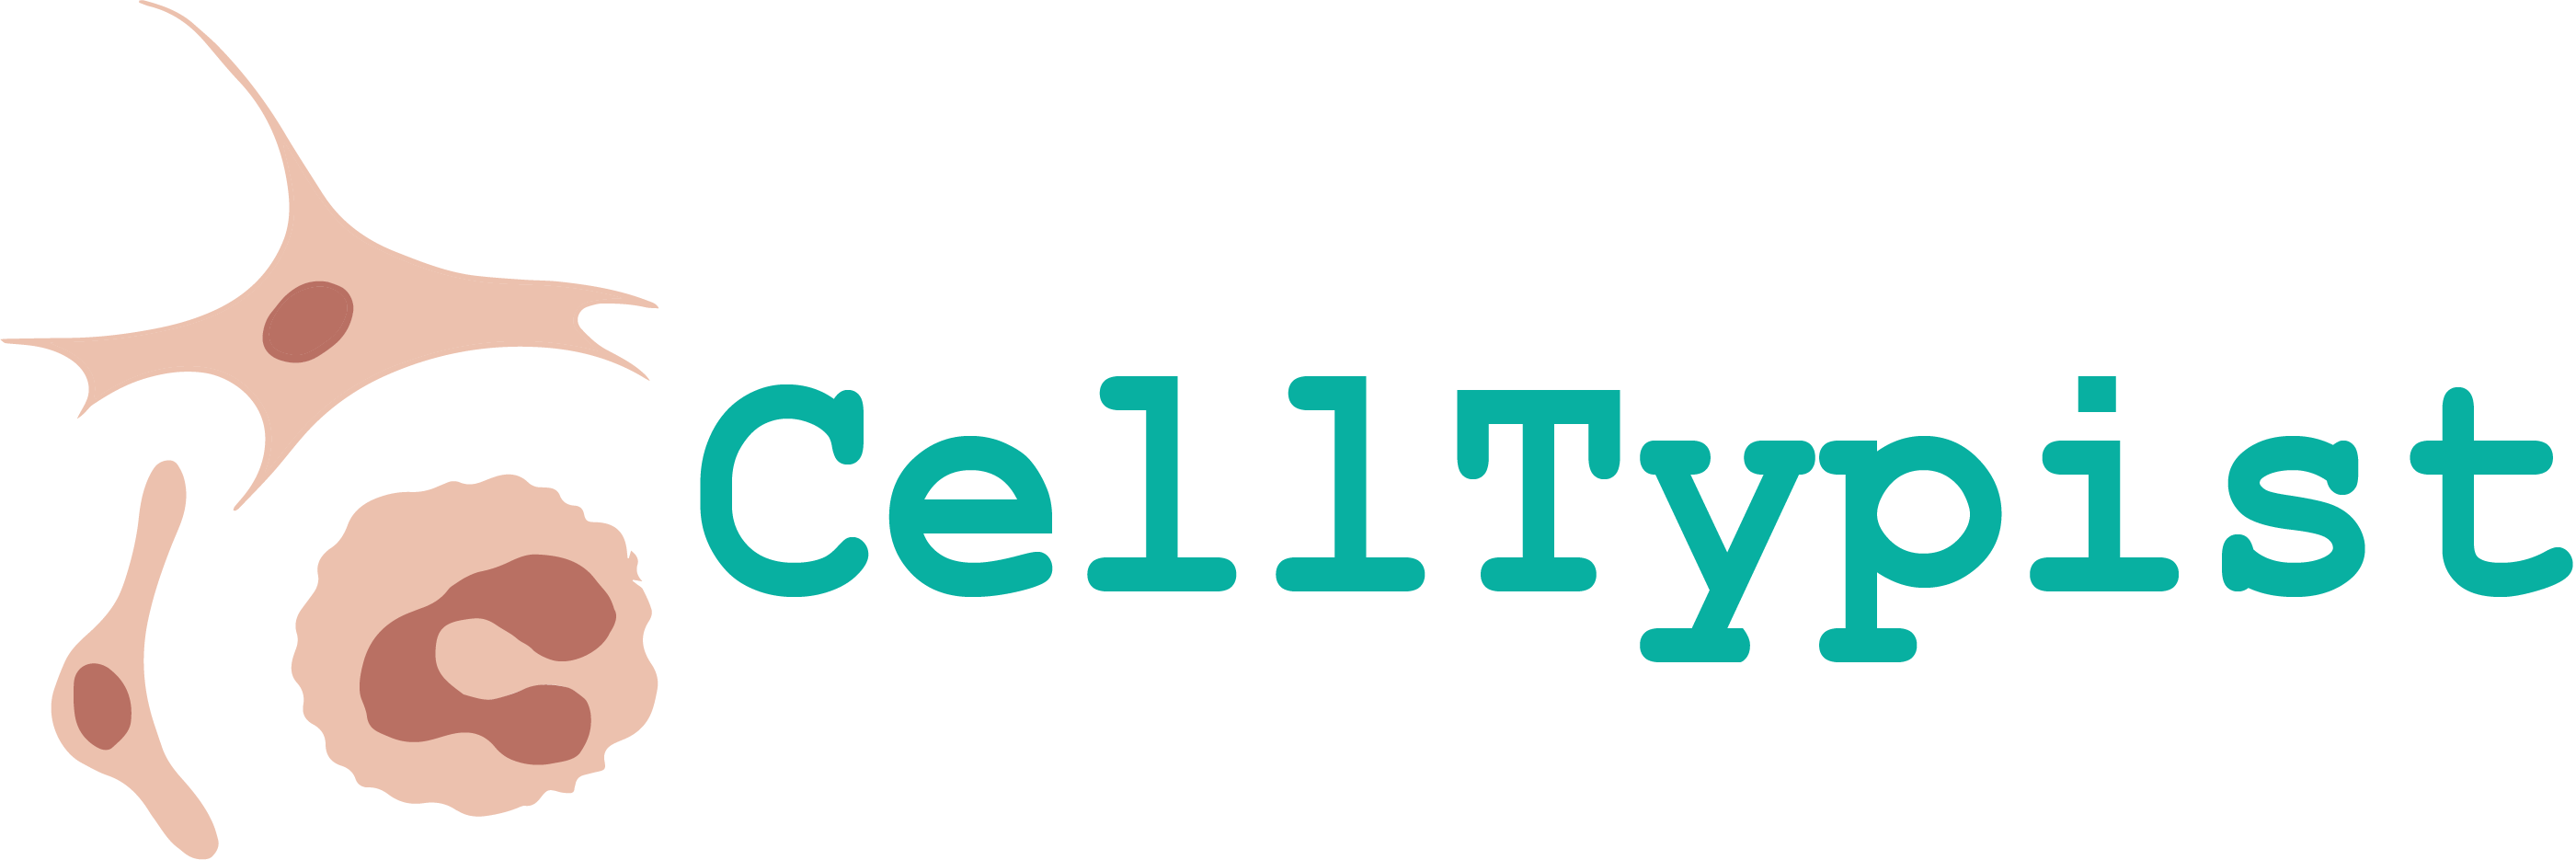

A detailed notebook on how to use CellTypist can be found [here](https://colab.research.google.com/github/Teichlab/celltypist/blob/main/docs/notebook/celltypist_tutorial.ipynb)

In [ ]:
!pip install celltypist

In [ ]:
import celltypist
# celltypist.models.download_models("Developing_Human_Brain.pkl")
celltypist.models.download_models('Immune_All_High.pkl')

In [ ]:
# import celltypist
from celltypist.models import Model
from celltypist import annotate



# Ensure the features (genes) match the model
adata.var_names = adata.var_names.str.upper()  # Convert gene names to uppercase if needed

In [ ]:
from celltypist.models import Model

# Load the model
model = Model.load("Immune_All_High.pkl")


# Check model details
print(model)

In [ ]:
import scanpy as sc

# Check if 'raw' layer exists and use it
if "raw" in adata.layers:
    adata.X = adata.layers["raw"].copy()
else:
    print("No raw count layer found! Check your original dataset.")

# Normalize counts per cell to 10,000
sc.pp.normalize_total(adata, target_sum=1e4)

# Log1p transformation
sc.pp.log1p(adata)

# Verify min/max values to check if data is in expected range
print(f"Min value: {adata.X.min()}, Max value: {adata.X.max()}")

In [ ]:
# Annotate cell types using the CellTypist model
predictions = annotate(adata, model="Immune_All_High.pkl", mode="best match")

# Add predictions to the AnnData object
adata.obs["celltypist_pred"] = predictions.predicted_labels

In [ ]:
import scanpy as sc

# UMAP plot with CellTypist predictions
sc.pl.umap(adata, color=["celltypist_pred"])
sc.pl.umap(adata, color=["leiden"])

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Extract leiden clusters and predicted cell types
df = adata.obs[['leiden', 'celltypist_pred']]

# Count occurrences of each cell type per Leiden cluster
counts = df.groupby(['leiden', 'celltypist_pred']).size().unstack(fill_value=0)

# Normalize counts per cluster to get proportions
counts_norm = counts.div(counts.sum(axis=1), axis=0)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define a discrete color palette (e.g., 'tab10' or 'Set3')
palette = sns.color_palette("tab10", n_colors=len(counts_norm.columns))  # Adjust colors based on unique cell types

# Set figure size
plt.figure(figsize=(12, 6))

# Create a stacked barplot with discrete colors
counts_norm.plot(
    kind='bar',
    stacked=True,
    color=palette,  # Apply discrete colors
    figsize=(12, 6)
)

# Customize plot
plt.xlabel("Leiden Clusters")
plt.ylabel("Proportion of Cell Types")
plt.title("Stacked Barplot of Cell Types per Leiden Cluster")
plt.legend(title="Cell Type", bbox_to_anchor=(1.05, 1), loc='upper left')

# Show plot
plt.tight_layout()
plt.show()


Above, majority vote indicates potential identities for each cell cluster. Below, stacked barplots indicate the composition of each cell cluster in terms of potential cell-types.

# Pathway enrichment

🔬 Pathway Enrichment in Single-Cell Analysis

📌 Overview
Pathway enrichment analysis identifies **biologically relevant pathways** that are significantly enriched in gene expression data. This helps in understanding **cellular responses, functional changes, and regulatory mechanisms** in different conditions.

---

🔹 1. Preprocessing Before Pathway Analysis
Before running enrichment analysis, ensure:
- **Data normalization** (e.g., log transformation, scaling)
- **Identification of differentially expressed genes (DEGs)**
- **Mapping genes to pathway databases (e.g., KEGG, Reactome, GO, MSigDB)**

Example of **DEG analysis** using Scanpy:
```python
import scanpy as sc

# Rank genes by differential expression
sc.tl.rank_genes_groups(adata, groupby="cell_type", method="wilcoxon")
sc.pl.rank_genes_groups(adata, n_genes=5, sharey=False)


In this notebook we showcase how to use `decoupler` for functional enrichment.

In [ ]:
!pip install decoupler

In [ ]:
import decoupler as dc

The Molecular Signatures Database (MSigDB) is a resource containing a collection of gene sets annotated to different biological processes.


In [ ]:
msigdb = dc.get_resource('MSigDB')
msigdb

In [ ]:
# Filter by hallmark
msigdb = msigdb[msigdb['collection']=='hallmark']

# Remove duplicated entries
msigdb = msigdb[~msigdb.duplicated(['geneset', 'genesymbol'])]
msigdb

To infer functional enrichment scores we will run the Over Representation Analysis `ora` method. As input data it accepts an expression matrix `decoupler.run_ora` or the results of differential expression analysis `decoupler.run_ora_df`. For the former, by default the top 5% of expressed genes by sample are selected as the set of interest `S`, and for the latter a user-defined significance filtering can be used. Once we have S, it builds a contingency table using set operations for each set stored in the gene set resource being used `net`. Using the contingency table, `ora` performs a one-sided Fisher exact test to test for significance of overlap between sets. The final score is obtained by log-transforming the obtained p-values, meaning that higher values are more significant.

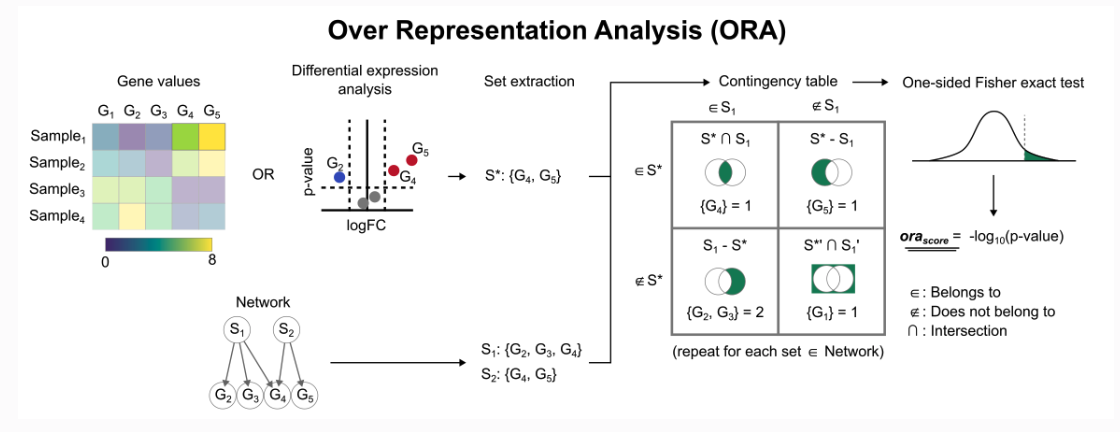

In [ ]:
dc.run_ora(
    mat=adata,
    net=msigdb,
    source='geneset',
    target='genesymbol',
    verbose=True, use_raw=False
)

In [ ]:
adata.obsm['ora_estimate']

In [ ]:
acts = dc.get_acts(adata, obsm_key='ora_estimate')

# We need to remove inf and set them to the maximum value observed
acts_v = acts.X.ravel()
max_e = np.nanmax(acts_v[np.isfinite(acts_v)])
acts.X[~np.isfinite(acts.X)] = max_e

acts

In [ ]:
sc.pl.umap(acts, color=["HALLMARK_KRAS_SIGNALING_DN", 'leiden'], cmap='RdBu_r')
sc.pl.violin(acts, keys=["HALLMARK_KRAS_SIGNALING_DN"], groupby='leiden', rotation=90)

Let’s identify which are the top gene sets per cell type. We can do it by using the function `dc.rank_sources_groups`, which identifies marker gene sets using the same statistical tests available in scanpy’s `scanpy.tl.rank_genes_groups`.

In [ ]:
df = dc.rank_sources_groups(acts, groupby='leiden', reference='rest', method='t-test_overestim_var')
df

In [ ]:
n_markers = 3
source_markers = df.groupby('group').head(n_markers).groupby('group')['names'].apply(lambda x: list(x)).to_dict()
source_markers

In [ ]:
sc.pl.matrixplot(acts, source_markers, 'leiden', dendrogram=True, standard_scale='var',
                 colorbar_title='Z-scaled scores', cmap='RdBu_r')

# Data Integration

The following data has been used in the scGen paper {cite:p}`Lotfollahi2019`, has been used [here][batch-removal],
was curated [here][curation] and can be downloaded from [here (the BBKNN paper)][paper].

It contains data for human pancreas from 4 different studies {cite:p}`Segerstolpe2016,Baron2016,Wang2016,Muraro2016`,
which have been used in the seminal papers on single-cell dataset integration {cite:p}`Butler2018,Haghverdi2018` and many times ever since.

[batch-removal]: https://nbviewer.jupyter.org/github/M0hammadL/scGen_notebooks/blob/master/notebooks/scgen_batch_removal.ipynb
[curation]: https://nbviewer.jupyter.org/github/Teichlab/bbknn/blob/master/examples/pancreas.ipynb
[paper]: ftp://ngs.sanger.ac.uk/production/teichmann/BBKNN/objects-pancreas.zip

In [ ]:
# note that this collection of batches is already intersected on the genes
adata_all = sc.read(
    "data/pancreas.h5ad",
    backup_url="https://www.dropbox.com/s/qj1jlm9w10wmt0u/pancreas.h5ad?dl=1",
)

In [ ]:
counts = adata_all.obs["celltype"].value_counts()
counts.to_frame()

In [ ]:
minority_classes = counts.index[-5:].tolist()  # get the minority classes
# actually subset
adata_all = adata_all[~adata_all.obs["celltype"].isin(minority_classes)].copy()
# reorder according to abundance
adata_all.obs["celltype"] = adata_all.obs["celltype"].cat.reorder_categories(counts.index[:-5].tolist())

In [ ]:
sc.pp.pca(adata_all)
sc.pp.neighbors(adata_all)
sc.tl.umap(adata_all)

We observe a batch effect.

In [ ]:
sc.pl.umap(adata_all, color=["batch", "celltype"], palette=sc.pl.palettes.vega_20_scanpy)

It can be well-resolved using [BBKNN](https://github.com/Teichlab/bbknn) {cite:p}`Polanski2019`.

In [ ]:
%%time
sc.external.pp.bbknn(adata_all, batch_key="batch")

In [ ]:
sc.tl.umap(adata_all)

In [ ]:
sc.pl.umap(adata_all, color=["batch", "celltype"])

# Trajectory pseudotime